# North Carolina Crash Data: Preliminary Exploration

This notebook provides an initial exploration of the North Carolina
Department of Transportation (NCDOT) statewide crash dataset used in
this project.

## Purpose

The goal of this notebook is to understand the structure, coverage,
quality, and basic distributions of the data before conducting the
project's feature-specific analyses.

The main project analysis focuses on the five complete calendar years:

**2021–2025**

Detailed geographic/severity analysis and crash-factor analysis are
implemented separately in the project's feature branches.

## Important

This notebook does not modify the raw NCDOT dataset. Data are loaded
through the shared preprocessing pipeline in `src/preprocessing.py`.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# Add the repository root to Python's module search path so that
# shared project modules under src/ can be imported from this notebook.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_crash_data

In [2]:
# Load the crash dataset using the project's shared preprocessing
# pipeline. By default, this retains only the complete years 2021–2025
# and creates the shared engineered features used throughout the project.

df = load_crash_data()

print("Dataset loaded successfully.")
print(f"Number of crash records: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully.
Number of crash records: 1,535,119
Number of columns: 35


In [4]:
print(f"Dataset shape: {df.shape}")

print(
    f"Date range: "
    f"{df['Date'].min().date()} to {df['Date'].max().date()}"
)

print(
    "Years included:",
    sorted(df["Year"].dropna().unique().tolist())
)

print(
    f"Unique counties represented: "
    f"{df['County'].nunique()}"
)

Dataset shape: (1535119, 35)
Date range: 2021-01-01 to 2025-12-31
Years included: [2021, 2022, 2023, 2024, 2025]
Unique counties represented: 100


In [5]:
# Display all available columns.
pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values
})

,column,dtype
0,Crash_ID,int64
1,Date,datetime64[ns]
2,Year,int64
3,Month,int64
4,County,object
5,City,object
6,Division,int64
7,MPORPO,object
8,CrshSeverity,string
9,NumFatalities,int64


In [6]:
df.head()

,Crash_ID,Date,Year,Month,County,City,Division,MPORPO,CrshSeverity,NumFatalities,...,TeenDrvrInvolved,UnbeltedCrash,NumUnbeltedFatalities,MotorcycleInvolved,HvyTruckInvolved,PedInvolved,BikeInvolved,is_fatal,is_serious,area_type
0,107837394,2024-08-31,2024,8,Durham,Durham,5,Triangle West TPO,O,0,...,False,False,0,False,False,False,False,False,False,Municipal/City
1,107833798,2024-08-29,2024,8,Nash,Rural,4,Upper Coastal Plain RPO,O,0,...,False,False,0,False,False,False,False,False,False,Rural
2,107837014,2024-08-31,2024,8,Cumberland,Fayetteville,6,Fayetteville Area MPO,O,0,...,False,False,0,False,False,False,False,False,False,Municipal/City
3,107837018,2024-09-01,2024,9,Cumberland,Fayetteville,6,Fayetteville Area MPO,O,0,...,False,False,0,False,False,False,False,False,False,Municipal/City
4,107837021,2024-09-01,2024,9,Cumberland,Fayetteville,6,Fayetteville Area MPO,O,0,...,False,False,0,False,False,False,False,False,False,Municipal/City


In [7]:
preview_columns = [
    "Crash_ID",
    "Date",
    "Year",
    "County",
    "City",
    "CrshSeverity",
    "CrashType",
    "is_fatal",
    "is_serious",
    "area_type",
]

df[preview_columns].head(10)

,Crash_ID,Date,Year,County,City,CrshSeverity,CrashType,is_fatal,is_serious,area_type
0,107837394,2024-08-31,2024,Durham,Durham,O,ANGLE,False,False,Municipal/City
1,107833798,2024-08-29,2024,Nash,Rural,O,ANIMAL,False,False,Rural
2,107837014,2024-08-31,2024,Cumberland,Fayetteville,O,"SIDESWIPE, SAME DIRECTION",False,False,Municipal/City
3,107837018,2024-09-01,2024,Cumberland,Fayetteville,O,"REAR END, SLOW OR STOP",False,False,Municipal/City
4,107837021,2024-09-01,2024,Cumberland,Fayetteville,O,"REAR END, SLOW OR STOP",False,False,Municipal/City
5,108127192,2025-05-27,2025,Mecklenburg,Charlotte,O,"REAR END, TURN",False,False,Municipal/City
6,108127410,2025-05-31,2025,Gaston,Rural,O,MOVABLE OBJECT,False,False,Rural
13,107458735,2023-09-14,2023,Union,Rural,O,ANIMAL,False,False,Rural
14,107458779,2023-09-07,2023,Duplin,Rural,C,FIXED OBJECT,False,False,Rural
15,107458785,2023-09-15,2023,Sampson,Rural,O,ANIMAL,False,False,Rural


In [18]:
# Calculate missing-value counts and percentages for each column.
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
)

# Keep only columns that contain at least one missing value.
missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
]

# Show columns with the highest amount of missingness first.
missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_percent
City,2977,0.193926


In [19]:
if missing_summary.empty:
    print("No missing values were found in the analysis dataset.")
else:
    print(
        f"{len(missing_summary)} column(s) contain missing values."
    )

1 column(s) contain missing values.


In [9]:
yearly_crashes = (
    df.groupby("Year")
    .size()
    .rename("crash_count")
    .reset_index()
)

yearly_crashes

,Year,crash_count
0,2021,307117
1,2022,302199
2,2023,311071
3,2024,310166
4,2025,304566


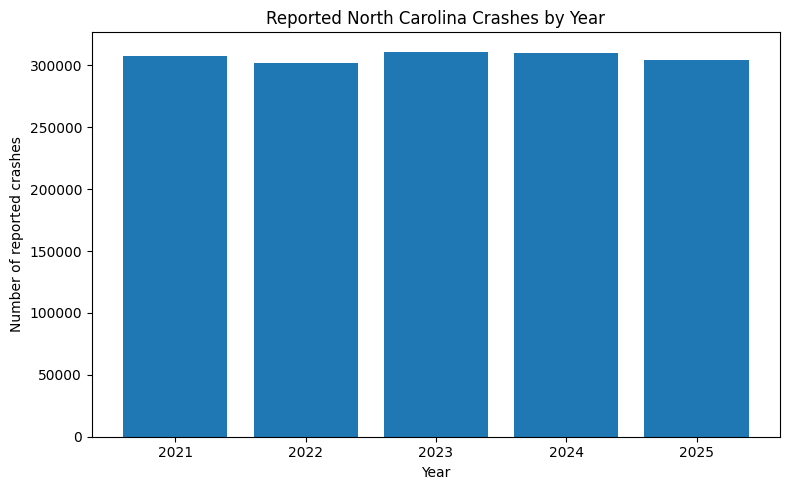

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    yearly_crashes["Year"].astype(str),
    yearly_crashes["crash_count"]
)

ax.set_title("Reported North Carolina Crashes by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of reported crashes")

plt.tight_layout()
plt.show()

In [11]:
severity_summary = (
    df["CrshSeverity"]
    .value_counts(dropna=False)
    .rename_axis("severity")
    .reset_index(name="crash_count")
)

severity_summary["percent"] = (
    severity_summary["crash_count"]
    / len(df)
    * 100
)

severity_summary

,severity,crash_count,percent
0,O,1103631,71.892212
1,C,225732,14.704528
2,B,119898,7.810339
3,U,56457,3.677695
4,A,21425,1.395657
5,K,7976,0.519569


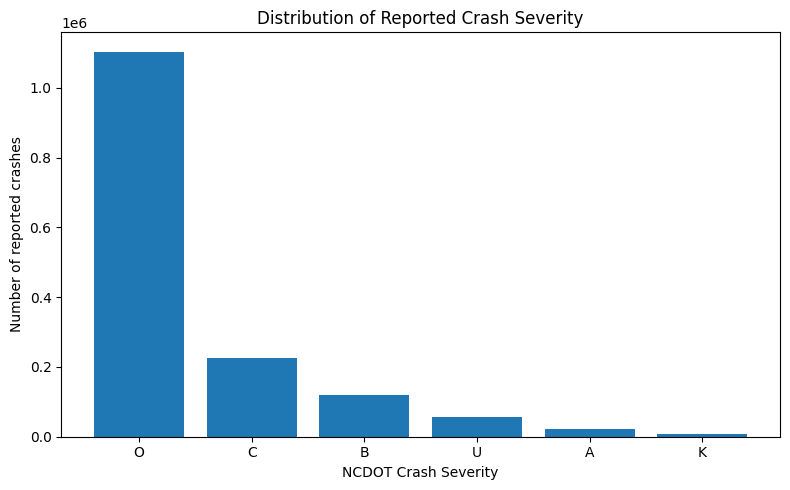

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    severity_summary["severity"].astype(str),
    severity_summary["crash_count"]
)

ax.set_title("Distribution of Reported Crash Severity")
ax.set_xlabel("NCDOT Crash Severity")
ax.set_ylabel("Number of reported crashes")

plt.tight_layout()
plt.show()

### NCDOT Severity Categories

The project uses NCDOT crash-severity codes, including:

- **K** — fatal injury
- **A** — serious/disabling injury
- **B** — evident injury
- **C** — possible injury
- **O** — no injury/property-damage-only crash

The project's primary serious-outcome indicator combines **K and A**
crashes through the engineered `is_serious` feature.

In [13]:
shared_features = [
    "is_fatal",
    "is_serious",
    "area_type",
]

df[shared_features].head()

,is_fatal,is_serious,area_type
0,False,False,Municipal/City
1,False,False,Rural
2,False,False,Municipal/City
3,False,False,Municipal/City
4,False,False,Municipal/City


In [14]:
print("Fatal crashes:")
print(df["is_fatal"].value_counts(dropna=False))

print("\nSerious crashes (K + A):")
print(df["is_serious"].value_counts(dropna=False))

print("\nArea classification:")
print(df["area_type"].value_counts(dropna=False))

Fatal crashes:
is_fatal
False    1527143
True        7976
Name: count, dtype: Int64

Serious crashes (K + A):
is_serious
False    1505718
True       29401
Name: count, dtype: int64

Area classification:
area_type
Municipal/City    994277
Rural             537865
Unknown             2977
Name: count, dtype: int64


In [15]:
quality_checks = {
    "duplicate_crash_ids": df["Crash_ID"].duplicated().sum(),
    "missing_crash_ids": df["Crash_ID"].isna().sum(),
    "missing_dates": df["Date"].isna().sum(),
    "missing_counties": df["County"].isna().sum(),
    "unexpected_years": (~df["Year"].isin([2021, 2022, 2023, 2024, 2025])).sum(),
}

pd.Series(
    quality_checks,
    name="count"
).to_frame()

,count
duplicate_crash_ids,0
missing_crash_ids,0
missing_dates,0
missing_counties,0
unexpected_years,0


In [16]:
pd.crosstab(
    df["CrshSeverity"],
    df["is_serious"],
    margins=True
)

is_serious,False,True,All
CrshSeverity,,,
A,0,21425,21425
B,119898,0,119898
C,225732,0,225732
K,0,7976,7976
O,1103631,0,1103631
U,56457,0,56457
All,1505718,29401,1535119


## Preliminary Exploration Summary

This notebook establishes the shared analytical foundation for the
project.

The preliminary exploration confirms:

- the dataset can be loaded reproducibly through the shared preprocessing
  pipeline;
- the primary analysis contains complete calendar years from 2021–2025;
- crash severity is represented using NCDOT severity categories;
- the project-level `is_serious` outcome correctly identifies K and A
  crashes;
- crash-factor indicators have been standardized for downstream analysis;
- missingness and basic identifier/date quality have been examined before
  feature-specific analysis.

The project now proceeds along two complementary analysis tracks:

**Geographic and Severity Analysis**  
Examines where crash frequency and serious crash outcomes differ across
North Carolina.

**Crash Factor and Temporal Analysis**  
Examines statewide trends and how recorded crash characteristics relate
to serious outcomes.

The two analyses use the same preprocessing pipeline and metric
definitions to maintain consistency across the project.

In [17]:
from src.metrics import serious_crash_count, serious_rate_per_1000

statewide_serious_count = serious_crash_count(df)
statewide_serious_rate = serious_rate_per_1000(df)

print(f"Total crashes analyzed: {len(df):,}")
print(f"Fatal/serious crashes: {statewide_serious_count:,}")
print(
    f"Statewide serious outcome rate: "
    f"{statewide_serious_rate:.2f} per 1,000 recorded crashes"
)

Total crashes analyzed: 1,535,119
Fatal/serious crashes: 29,401
Statewide serious outcome rate: 19.15 per 1,000 recorded crashes


In [3]:
from src.metrics import (
    known_severity_crash_count,
    serious_crash_count,
    serious_rate_per_1000,
)

statewide_serious_count = serious_crash_count(df)
known_severity_count = known_severity_crash_count(df)
statewide_serious_rate = serious_rate_per_1000(df)

print(f"Total crashes analyzed: {len(df):,}")
print(f"Crashes with known severity: {known_severity_count:,}")
print(f"Fatal/serious crashes (K + A): {statewide_serious_count:,}")
print(
    f"Statewide serious outcome rate: "
    f"{statewide_serious_rate:.2f} per 1,000 crashes with known severity"
)

Total crashes analyzed: 1,535,119
Crashes with known severity: 1,478,662
Fatal/serious crashes (K + A): 29,401
Statewide serious outcome rate: 19.88 per 1,000 crashes with known severity


The statewide Serious Outcome Rate serves as the common baseline for
subsequent geographic and crash-factor analyses.

Downstream feature branches will compare specific groups with this
statewide baseline rather than creating independent or arbitrary risk
scores.